<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/aula_9_regularized_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

In [2]:
# 1. Carregamento dos dados
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Ridge

In [4]:
# 2. Definição do Pipeline e da grade de alphas
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

alphas = np.logspace(-3, 3, 50) # 50 valores entre 10^-3 e 10^3
param_grid = {'ridge__alpha': alphas}
param_grid

{'ridge__alpha': array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
        3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
        9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
        2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
        9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
        2.81176870e-01, 3.72759372e-01, 4.94171336e-01, 6.55128557e-01,
        8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
        2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
        8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
        2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
        7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
        2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
        7.54312006e+02, 1.00000000e+03])}

In [5]:
# 3. Definição da estrutura de Cross-Validation (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# 4. Execução do Grid Search calculando a perda (MSE negativo)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    return_train_score=False
)
grid_search.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02...
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03])},
             scoring='neg_mean_squared_error')

In [7]:
# 4. Extração dos resultados do teste/validação fora da amostra
mse_test_scores = -grid_search.cv_results_['mean_test_score'] # Converte de negativo para MSE positivo
std_test_scores = grid_search.cv_results_['std_test_score']
best_alpha = grid_search.best_params_['ridge__alpha']
best_mse = grid_search.best_score_ * -1
print(f"Melhor Alfa encontrado: {best_alpha:.4f}")
print(f"Menor MSE obtido: {best_mse:.4f}")

Melhor Alfa encontrado: 19.3070
Menor MSE obtido: 0.5305


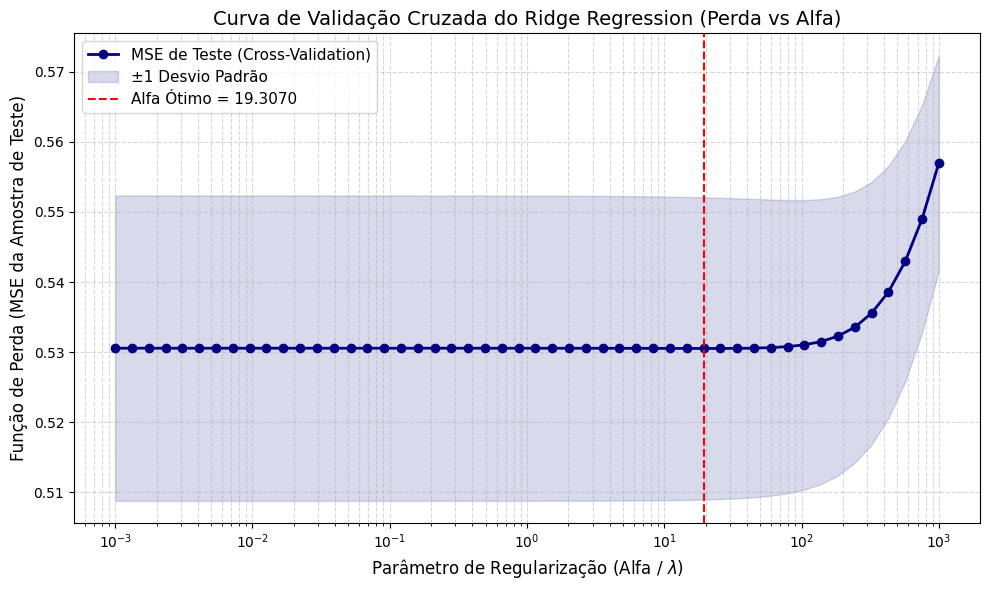

In [8]:
# 5. Construção do Gráfico de Perda vs Alfa
plt.figure(figsize=(10, 6))
plt.plot(alphas, mse_test_scores, marker='o', color='navy', linewidth=2, label='MSE de Teste (Cross-Validation)')
plt.fill_between(alphas, mse_test_scores - std_test_scores, mse_test_scores + std_test_scores, color='navy', alpha=0.15, label='±1 Desvio Padrão')

# Linha do Alfa Ótimo
plt.axvline(x=best_alpha, color='red', linestyle='--', linewidth=1.5, label=f'Alfa Ótimo = {best_alpha:.4f}')

plt.xscale('log') # Escala logarítmica para o eixo dos alfas
plt.xlabel(r'Parâmetro de Regularização (Alfa / $\lambda$)', fontsize=12) # Changed to raw string
plt.ylabel('Função de Perda (MSE da Amostra de Teste)', fontsize=12)
plt.title('Curva de Validação Cruzada do Ridge Regression (Perda vs Alfa)', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Lasso

In [9]:
from sklearn.linear_model import Lasso

# 2. Definição do Pipeline e da grade de alphas
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

alphas = np.logspace(-3, 3, 50) # 50 valores entre 10^-3 e 10^3
param_grid = {'ridge__alpha': alphas}
param_grid

{'ridge__alpha': array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
        3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
        9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02,
        2.94705170e-02, 3.90693994e-02, 5.17947468e-02, 6.86648845e-02,
        9.10298178e-02, 1.20679264e-01, 1.59985872e-01, 2.12095089e-01,
        2.81176870e-01, 3.72759372e-01, 4.94171336e-01, 6.55128557e-01,
        8.68511374e-01, 1.15139540e+00, 1.52641797e+00, 2.02358965e+00,
        2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
        8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
        2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
        7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
        2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
        7.54312006e+02, 1.00000000e+03])}

In [10]:
# 3. Definição da estrutura de Cross-Validation (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
# 4. Execução do Grid Search calculando a perda (MSE negativo)
param_grid = {'lasso__alpha': alphas}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    return_train_score=False
)
grid_search.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso())]),
             param_grid={'lasso__alpha': array([1.00000000e-03, 1.32571137e-03, 1.75751062e-03, 2.32995181e-03,
       3.08884360e-03, 4.09491506e-03, 5.42867544e-03, 7.19685673e-03,
       9.54095476e-03, 1.26485522e-02, 1.67683294e-02, 2.22299648e-02...
       2.68269580e+00, 3.55648031e+00, 4.71486636e+00, 6.25055193e+00,
       8.28642773e+00, 1.09854114e+01, 1.45634848e+01, 1.93069773e+01,
       2.55954792e+01, 3.39322177e+01, 4.49843267e+01, 5.96362332e+01,
       7.90604321e+01, 1.04811313e+02, 1.38949549e+02, 1.84206997e+02,
       2.44205309e+02, 3.23745754e+02, 4.29193426e+02, 5.68986603e+02,
       7.54312006e+02, 1.00000000e+03])},
             scoring='neg_mean_squared_error')

In [12]:
best_alpha = grid_search.best_params_['lasso__alpha']
best_mse = grid_search.best_score_ * -1
print(f"Melhor Alfa encontrado: {best_alpha:.4f}")
print(f"Menor MSE obtido: {best_mse:.4f}")

Melhor Alfa encontrado: 0.0023
Menor MSE obtido: 0.5302


# ElasticNet

In [13]:
from sklearn.linear_model import ElasticNet

# 2. Definição do Pipeline e da grade de alphas
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elastic_net', ElasticNet())
])

In [14]:
# 3. Definição da estrutura de Cross-Validation (K-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [15]:
# 4. Grade de Hiperparâmetros (Grid Search)
# 'alpha': força da penalização (lambda)
# 'l1_ratio': 1.0 é Lasso puramente, 0.0 é Ridge puramente
param_grid = {
    'elastic_net__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'elastic_net__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}
param_grid

{'elastic_net__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
 'elastic_net__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]}

In [16]:
# 5. Execução do Grid Search calculando a perda (MSE negativo)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    return_train_score=False
)
grid_search.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('elastic_net', ElasticNet())]),
             param_grid={'elastic_net__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
                         'elastic_net__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9,
                                                   1.0]},
             scoring='neg_mean_squared_error')

In [17]:
# 6. Resultados e Melhores Hiperparâmetros
print("--- Melhores Resultados ---")
print(f"Melhor combinação de parâmetros: {grid_search.best_params_}")
print(f"Melhor MSE (Validação Cruzada): {-grid_search.best_score_:.4f}")

--- Melhores Resultados ---
Melhor combinação de parâmetros: {'elastic_net__alpha': 0.001, 'elastic_net__l1_ratio': 1.0}
Melhor MSE (Validação Cruzada): 0.5303


# União dos três modelos em um único pipeline
## Vamos reiniciar a sessão do Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [2]:
# 1. Carregamento dos dados
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

In [3]:
# 2. Classe Wrapper com Cross-Validation embutido na Amostra de Treino
class RegularizedRegressionCVModel:
    def __init__(self, model_type='ridge', inner_cv=5):
        """
        model_type: 'ridge', 'lasso', 'elasticnet'
        inner_cv: número de folds para a validação cruzada interna no conjunto de treino
        """
        self.model_type = model_type.lower()
        self.inner_cv = inner_cv
        self.best_params_ = None
        pipe, param_grid = self._get_pipeline_and_params()

        inner_kf = KFold(n_splits=self.inner_cv,
                         shuffle=True,
                         random_state=42)
        self.grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=inner_kf,
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )

    def _get_pipeline_and_params(self):
        # Definição do Pipeline base (Scaler + Modelo)
        if self.model_type == 'ridge':
            pipe = Pipeline([('scaler', StandardScaler()),
                             ('model', Ridge())])
            param_grid = {'model__alpha': np.logspace(-3, 3, 30)}
        elif self.model_type == 'lasso':
            pipe = Pipeline([('scaler', StandardScaler()),
                             ('model', Lasso())])
            param_grid = {'model__alpha': np.logspace(-4, 1, 30)}
        elif self.model_type == 'elasticnet':
            pipe = Pipeline([('scaler', StandardScaler()),
                             ('model', ElasticNet())])
            param_grid = {
                'model__alpha': np.logspace(-4, 1, 15),
                'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
            }
        else:
            raise ValueError("Tipo de modelo inválido. Escolha 'ridge', 'lasso' ou 'elasticnet'.")
        return pipe, param_grid

    def fit(self, X_train, y_train):
        # Ajusta e realiza o CV restrito à amostra de treino
        self.grid_search.fit(X_train, y_train)
        self.best_params_ = self.grid_search.best_params_
        return self

    def predict(self, X_test):
        return self.grid_search.predict(X_test)

In [4]:
# 3. Validação Cruzada Externa (5-Fold)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [5]:
models_to_evaluate = [
    ('Ridge (L2)', 'ridge'),
    ('Lasso (L1)', 'lasso'),
    ('Elastic-Net', 'elasticnet')
]

In [7]:
all_metrics = []

for model_name, model_type in models_to_evaluate:

      # Instanciar e rodar o CV interno no treino
      regressor = RegularizedRegressionCVModel(model_type=model_type, inner_cv=5)
      regressor.fit(X_train, y_train)

      # Previsão no teste externo
      preds = regressor.predict(X_test)

      # Métricas de desempenho fora da amostra
      mse = mean_squared_error(y_test, preds)
      mae = mean_absolute_error(y_test, preds)
      mape = mean_absolute_percentage_error(y_test, preds)
      mpe = np.mean((y_test - preds) / y_test)

      all_metrics.append({
          'Model': model_name,
          'Best Params': str(regressor.best_params_) if regressor.best_params_ else 'N/A',
          'MSE': mse,
          'MAE': mae,
          'MAPE': mape,
          'MPE': mpe
      })

# 4. Agregação e Exibição dos Resultados
results_df = pd.DataFrame(all_metrics)
summary_df = results_df.groupby('Model')[['MSE', 'MAE', 'MAPE', 'MPE']].mean()

display(summary_df)

,MSE,MAE,MAPE,MPE
Model,,,,
Elastic-Net,0.536798,0.529577,0.317846,-0.124578
Lasso (L1),0.536708,0.529583,0.317839,-0.124703
Ridge (L2),0.536966,0.529571,0.317863,-0.124320


# Atividade:
## 1. Como o desempenho do OLS (mínimos quadrados ordinários) se comparar aos modelos regularizados?